# Tugas 2 — Analisis Sinyal Suara & Noise Statis
**IF25-40305 Sistem Teknologi Multimedia — Week 03**

Nama   : Mohd. Musyaffa Alief Athallah  
NIM    : 123140184  
Prodi  : Teknik Informatika, Institut Teknologi Sumatera

Tautan : https://github.com/Escavora/stm-if25-40305-123140184/tree/main/02_audio_noise_statis

---

## Skenario Perekaman
- **Sumber noise statis:** Kipas angin berdiri dengan kecepatan 3
- **Jarak ke sumber derau:** +- 70 cm
- **Perangkat perekam:** iPhone 13
- **Artikel yang dibacakan:** Kabut asap karhutla menyelimuti pekanbaru, disdik perpanjang pjj untuk siswa

### 1. Import dan konfigurasi

In [1]:
# get_window diimpor terpisah karena window Hann yang dipakai nanti harus
# versi PERIODIK (fftbins=True). np.hanning bawaan NumPy itu simetris, kurang
# pas buat analisis spektrum. librosa.display juga harus diimpor sendiri,
# soalnya nggak ikut kebawa pas "import librosa".

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from IPython.display import display

# dpi dinaikin ke 120 biar grafiknya tetap tajam pas notebook diekspor ke PDF
# buat dikumpulin di Moodle.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Palet warna buat visualisasi
C_SIGNAL  = '#0284c7'   # biru   - sinyal utama
C_NEUTRAL = '#334155'   # slate  - audio mentah
C_ALERT   = '#dc2626'   # merah  - cacat / batas bahaya
C_GOOD    = '#059669'   # hijau  - kondisi benar
C_ACCENT  = '#7c3aed'   # violet - sorotan

### 2. Muat audio dan inspeksi data

In [2]:
AUDIO_PATH = 'audio_original.wav'

# sr=None WAJIB. Tanpa ini librosa diam-diam nge-resample ke 22.050 Hz, jadi
# laju sampel, jumlah sampel, dan Nyquist di bawah bukan punya berkas asli lagi.
# mono=True nggabungin stereo jadi satu kanal biar analisisnya 1 dimensi.
y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)

durasi = len(y) / sr

print("=== METADATA SINYAL AUDIO ===")
print(f"Nama berkas          : {AUDIO_PATH}")
print(f"Laju sampel asli (fs): {sr} Hz")
print(f"Jumlah sampel total  : {len(y)} sampel")
print(f"Durasi rekaman       : {durasi:.3f} detik")
print(f"Batas Nyquist        : {sr/2:.1f} Hz")
print()
print(f"Amplitudo minimum    : {y.min():+.6f}")
print(f"Amplitudo maksimum   : {y.max():+.6f}")
print(f"Puncak absolut       : {np.max(np.abs(y)):.6f} "
      f"({20*np.log10(np.max(np.abs(y))):.2f} dBFS)")
print(f"Nilai RMS            : {np.sqrt(np.mean(y**2)):.6f} "
      f"({20*np.log10(np.sqrt(np.mean(y**2))):.2f} dBFS)")

# Pemutar audio buat dicek pakai telinga
print("\nRekaman asli:")
display(ipd.Audio(y, rate=sr))

=== METADATA SINYAL AUDIO ===
Nama berkas          : audio_original.wav
Laju sampel asli (fs): 48000 Hz
Jumlah sampel total  : 974848 sampel
Durasi rekaman       : 20.309 detik
Batas Nyquist        : 24000.0 Hz

Amplitudo minimum    : -0.921295
Amplitudo maksimum   : +0.949463
Puncak absolut       : 0.949463 (-0.45 dBFS)
Nilai RMS            : 0.188797 (-14.48 dBFS)

Rekaman asli:


Puncak absolut ngasih tahu "titik paling kerasnya seberapa", RMS ngasih tahu "energi rata-ratanya seberapa". Selisih keduanya disebut crest factor, tanda seberapa dinamis rekamannya.

### 3. Interpretasi pribadi

Berkas dimuat apa adanya di 48.000 Hz, laju yang umum buat audio video profesional. sr=None dipakai supaya librosa nggak diam-diam nurunin ke 22.050 Hz, jadi semua angka di atas memang punya berkas asli. Akibatnya batas Nyquist ada di 24.000 Hz, dan batas ini yang nentuin semua analisis setelahnya.

Amplitudonya hampir simetris terhadap nol (-0,921 dan +0,949), jadi nggak ada DC offset. Yang menarik puncaknya: -0,45 dBFS, cuma kurang dari setengah desibel dari batas maksimal digital. Belum clipping, tapi mepet. Kemungkinan ini gara-gara penguatan otomatis di iPhone yang suka dorong level sedekat mungkin ke batas. RMS-nya -14,48 dBFS, energi rata-rata yang sehat. Selisih sekitar 14 dB antara puncak dan RMS artinya rekaman masih punya dinamika yang cukup lebar antara jeda dan bagian bicara.

### 4. Visualisasi 1. Waveform (Amplitudo vs Waktu)

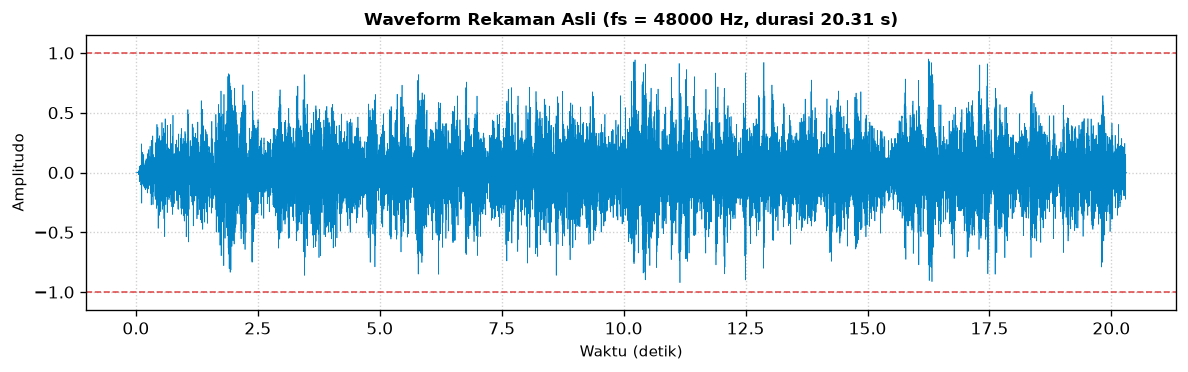

=== PERBANDINGAN NOISE FLOOR vs SINYAL AKTIF ===
Jendela paling hening di detik ke-0.30
  RMS noise floor    : 0.105070 (-19.57 dBFS)
Jendela paling aktif di detik ke-10.54
  RMS sinyal + noise : 0.271778 (-11.32 dBFS)

Selisih (perkiraan SNR kasar): 8.25 dB


In [3]:
t = np.arange(len(y)) / sr

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t, y, color=C_SIGNAL, lw=0.4)

# Garis putus-putus di +1,0 dan -1,0 itu plafon digital 0 dBFS. Kalau ada
# puncak yang nyentuh terus kepotong rata di sini, berarti clipping.
for batas in (1.0, -1.0):
    ax.axhline(batas, color=C_ALERT, lw=1.0, linestyle='--', alpha=0.8)

ax.set_title(f"Waveform Rekaman Asli (fs = {sr} Hz, durasi {durasi:.2f} s)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.set_ylim(-1.15, 1.15)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Bagian paling hening dicari otomatis, bukan ditebak pakai mata.
# np.abs(y) jadi envelope kasar, terus dihaluskan pakai rata-rata 300 ms
# biar yang kelihatan tinggal tren energinya. Irisan [win : len(y)-win]
# ngindarin tepi array, karena mode 'same' di situ hasilnya bias.
win = int(0.3 * sr)
env = np.abs(y)
energi = np.convolve(env, np.ones(win) / win, mode='same')

i_hening = int(np.argmin(energi[win:len(y) - win])) + win
i_aktif  = int(np.argmax(energi[win:len(y) - win])) + win

seg_hening = y[i_hening - win // 2 : i_hening + win // 2]
seg_aktif  = y[i_aktif  - win // 2 : i_aktif  + win // 2]

rms_hening = np.sqrt(np.mean(seg_hening ** 2))
rms_aktif  = np.sqrt(np.mean(seg_aktif ** 2))

print("=== PERBANDINGAN NOISE FLOOR vs SINYAL AKTIF ===")
# Dibandingin pakai RMS, bukan puncak. Puncak gampang kacau gara-gara satu
# ketukan doang, sedangkan RMS mewakili energi keseluruhan.
print(f"Jendela paling hening di detik ke-{i_hening/sr:.2f}")
print(f"  RMS noise floor    : {rms_hening:.6f} ({20*np.log10(rms_hening):.2f} dBFS)")
print(f"Jendela paling aktif di detik ke-{i_aktif/sr:.2f}")
print(f"  RMS sinyal + noise : {rms_aktif:.6f} ({20*np.log10(rms_aktif):.2f} dBFS)")
print(f"\nSelisih (perkiraan SNR kasar): {20*np.log10(rms_aktif/rms_hening):.2f} dB")

- Lanjut zoom kedua bagian berdampingan biar kontrasnya kelihatan.

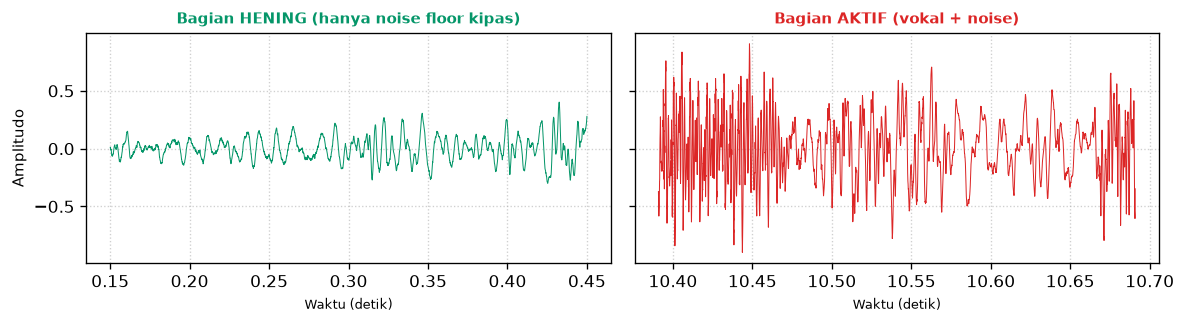

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True)

for ax, seg, i_pusat, judul, warna in (
    (axes[0], seg_hening, i_hening, 'Bagian HENING (hanya noise floor kipas)', C_GOOD),
    (axes[1], seg_aktif,  i_aktif,  'Bagian AKTIF (vokal + noise)',            C_ALERT),
):
    t_seg = (np.arange(len(seg)) + i_pusat - win // 2) / sr
    ax.plot(t_seg, seg, color=warna, lw=0.6)
    ax.set_title(judul, fontsize=9, fontweight='bold', color=warna)
    ax.set_xlabel("Waktu (detik)", fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel("Amplitudo", fontsize=9)
plt.tight_layout()
plt.show()

Waveform cuma bisa jawab "kapan", bukan "apa". Dari gambar utuhnya, sinyal mengisi hampir seluruh bingkai tapi nggak pernah nyentuh garis +1,0 atau -1,0. Jadi memang nggak clipping, meski mepet.

Yang lebih menarik ada di perbandingan dua jendela. Panel kiri (potongan hening di detik 0,30) ternyata nggak rata di nol, ada osilasi halus sekitar 0,1 yang goyang terus. Itu deru kipas, sudah ada bahkan sebelum saya ngomong. Panel kanan beda jauh: amplitudo naik sampai hampir 0,9, polanya lebih runcing dan nggak beraturan. RMS noise floor -19,57 dBFS, RMS bagian aktif -11,32 dBFS, selisihnya 8,25 dB.

Selisih 8 dB itu sebenarnya kecil. Kipas kecepatan tiga di jarak 70 cm ternyata cukup keras, dan saya baru sadar dari angka ini, bukan dari telinga. Tapi di sini juga kelihatan batas waveform: dia cuma bisa nunjukin seberapa keras, nggak bisa nunjukin nada apa. Dentuman rendah dan desis tinggi yang sama kerasnya bakal kelihatan sama tinggi. Buat itu, harus lihat domain frekuensi.

### 5. Visualisasi 2. Spektrum FFT Terkalibrasi dBFS

In [5]:
def spectrum_dbfs(x, sr, n_fft=8192, average=True):
    """Ngitung spektrum satu sisi dalam dBFS yang sudah terkalibrasi.

    Kalau cuma 20*log10(abs(rfft(x))), BENTUK kurvanya benar tapi ANGKANYA
    ngaco, karena nilainya ikut berubah tiap panjang potongan berubah.
    Ada dua koreksi buat benerin itu:

    1. Dibagi np.sum(w), bukan panjang sinyal N. Window Hann ngeredam kedua
       tepi potongan jadi energinya berkurang, dan pembagian ini yang
       ngembaliin. Kalau dilewatin, semua bacaan geser sekitar 6 dB.
    2. Dikali 2 karena rfft cuma ngasih separuh spektrum, padahal energi
       sinyal nyata kebagi ke frekuensi positif dan negatif. Bin DC dan bin
       Nyquist nggak ikut dikali (irisan [1:-1]) karena nggak punya pasangan.

    Rata-rata dari banyak jendela yang tumpang tindih 50% bikin suara yang
    datang-pergi saling redam, sedangkan yang konstan kayak kipas makin nonjol.
    """
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))

    w = get_window('hann', n_fft, fftbins=True) # window periodik buat FFT
    hop = n_fft // 2
    n_frames = 1 + (len(x) - n_fft) // hop if average else 1

    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frames):
        seg = x[i * hop : i * hop + n_fft]
        akumulasi += np.abs(np.fft.rfft(seg * w))
    mag = akumulasi / n_frames / np.sum(w)

    mag[1:-1] *= 2.0 # koreksi spektrum satu sisi
    db = 20 * np.log10(np.maximum(mag, 1e-12))
    return np.fft.rfftfreq(n_fft, 1 / sr), db

# Dites dulu sebelum grafiknya dipercaya. Nada amplitudo 1,0 harus puncak di
# 0 dBFS, amplitudo 0,5 di -6,02 dBFS. Frekuensi ujinya sengaja diambil dari
# f_bins biar jatuh pas di tengah bin, jadi nggak kena scalloping loss yang
# bisa nurunin bacaan ~0,3 dB.
N_UJI = 8192
f_bins = np.fft.rfftfreq(N_UJI, 1 / sr)
f_uji = f_bins[171] # nada tepat di tengah bin
t_uji = np.arange(N_UJI) / sr

print("Verifikasi kalibrasi dBFS:")
for amp in (1.0, 0.5, 0.1):
    _, db_uji = spectrum_dbfs(amp * np.sin(2 * np.pi * f_uji * t_uji), sr, n_fft=N_UJI)
    print(f"  amplitudo {amp:<4} -> puncak {db_uji.max():8.4f} dBFS "
          f"(target {20*np.log10(amp):7.2f} dBFS)")
print("\nSelisihnya nol, sumbu dBFS pada grafik berikut benar dan sesuai ketentuan.\n")

Verifikasi kalibrasi dBFS:
  amplitudo 1.0  -> puncak   0.0000 dBFS (target    0.00 dBFS)
  amplitudo 0.5  -> puncak  -6.0206 dBFS (target   -6.02 dBFS)
  amplitudo 0.1  -> puncak -20.0000 dBFS (target  -20.00 dBFS)

Selisihnya nol, sumbu dBFS pada grafik berikut benar dan sesuai ketentuan.



- Lanjut plot spektrum rekaman, dibandingin sama potongan hening biar karakter deraunya kelihatan sendiri.

Potongan hening : detik 0.00 s.d. 1.30 (62400 sampel)


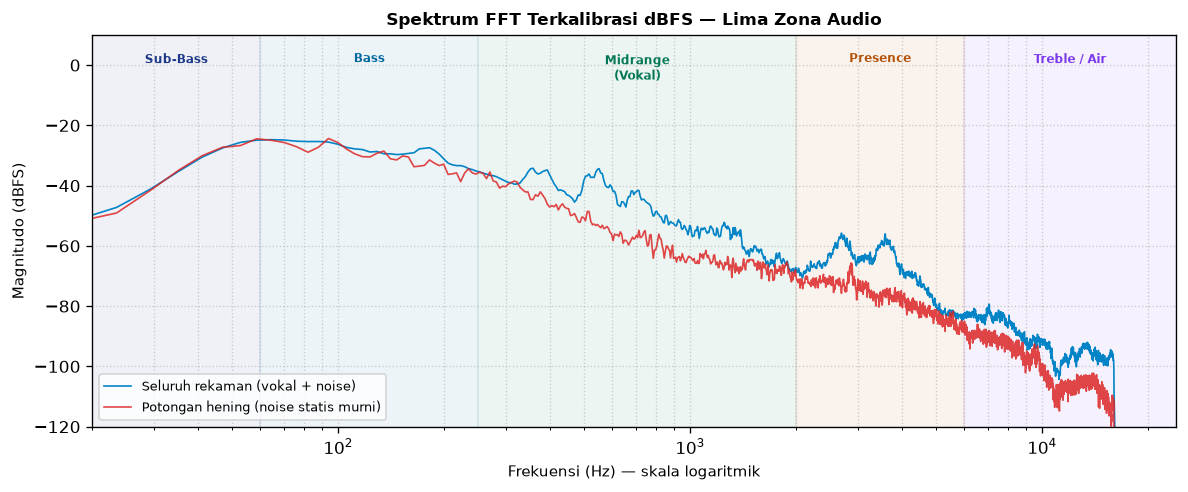

Frekuensi dominan pada noise statis : 93.8 Hz (-24.35 dBFS)

Lima komponen terkuat pada noise statis:
      93.8 Hz ->  -24.35 dBFS
      58.6 Hz ->  -24.47 dBFS
      64.5 Hz ->  -24.94 dBFS
      99.6 Hz ->  -25.66 dBFS
      70.3 Hz ->  -25.71 dBFS


In [6]:
N_FFT_SPEC = 8192

# --- Ambil potongan hening ---
# Diambil 1 detik sebelum dan sesudah titik paling hening.
# np.clip WAJIB. Titik hening di rekaman ini ada di detik 0,43, jadi
# i_hening - sr hasilnya negatif. NumPy baca indeks negatif sebagai hitungan
# dari belakang, akibatnya slice kosong dan spektrumnya cuma deretan nol
# (-240 dBFS). Ini nggak bikin error, jadi harus dicegah sendiri.
lo = int(np.clip(i_hening - sr, 0, len(y)))
hi = int(np.clip(i_hening + sr, 0, len(y)))
potongan_hening = y[lo:hi]

print(f"Potongan hening : detik {lo/sr:.2f} s.d. {hi/sr:.2f} "
      f"({len(potongan_hening)} sampel)")

# --- Hitung spektrum ---
# db_full   : seluruh rekaman, isinya vokal + derau kipas.
# db_hening : cuma bagian hening, jadi isinya murni noise statis.
# Dibandingin biar kelihatan mana yang punya derau, mana yang punya suara.
freqs, db_full   = spectrum_dbfs(y, sr, n_fft=N_FFT_SPEC)
_,     db_hening = spectrum_dbfs(potongan_hening, sr, n_fft=N_FFT_SPEC)

# Lima zona spektrum audio yang biasa dipakai buat acuan setting Equalizer
ZONA = [
    (20,   60,    'Sub-Bass',          '#1e3a8a'),
    (60,   250,   'Bass',              '#0369a1'),
    (250,  2000,  'Midrange\n(Vokal)', '#047857'),
    (2000, 6000,  'Presence',          '#b45309'),
    (6000, 24000, 'Treble / Air',      '#7c3aed'),
]

fig, ax = plt.subplots(figsize=(10, 4.2))
for f_lo, f_hi, label, warna in ZONA:
    ax.axvspan(f_lo, f_hi, color=warna, alpha=0.07)
    # Label ditaruh di rata-rata geometrik batasnya, bukan rata-rata biasa,
    # karena sumbu X-nya logaritmik.
    ax.text(np.sqrt(f_lo * f_hi), 4, label, ha='center', va='top',
            fontsize=7, fontweight='bold', color=warna)

# Mulai dari indeks 1 buat buang bin DC (0 Hz). Di skala log, nol nggak bisa
# digambar dan bakal bikin matplotlib ngasih warning.
ax.semilogx(freqs[1:], db_full[1:],   color=C_SIGNAL, lw=1.0,
            label='Seluruh rekaman (vokal + noise)')
ax.semilogx(freqs[1:], db_hening[1:], color=C_ALERT,  lw=1.0, alpha=0.85,
            label='Potongan hening (noise statis murni)')

ax.set_title("Spektrum FFT Terkalibrasi dBFS — Lima Zona Audio",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, sr / 2)
ax.set_ylim(-120, 10)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Cari frekuensi dominan derau ---
# Dibatasi 30 s.d. 2000 Hz. Batas bawah buat ngindarin gemuruh infrasonik dan
# sisa DC, batas atas fokus ke wilayah deru motor kipas dan harmoniknya.
mask = (freqs > 30) & (freqs < 2000)
idx_dom = np.where(mask)[0][np.argmax(db_hening[mask])]
print(f"Frekuensi dominan pada noise statis : {freqs[idx_dom]:.1f} Hz "
      f"({db_hening[idx_dom]:.2f} dBFS)")

# Lima puncak teratas, buat ngecek deraunya harmonik atau nggak
urut = np.argsort(db_hening[mask])[::-1][:5]
print("\nLima komponen terkuat pada noise statis:")
for k in urut:
    i = np.where(mask)[0][k]
    print(f"  {freqs[i]:8.1f} Hz -> {db_hening[i]:7.2f} dBFS")

Sebelum nyimpulin apa pun, sumbunya harus dicek dulu. Amplitudo 1,0 puncaknya tepat di 0,0000 dBFS, amplitudo 0,5 tepat di -6,0206 dBFS, sama persis dengan teori. Jadi sumbu Y ini memang terkalibrasi, bukan cuma angka relatif.

Bandingin dua kurva ternyata jauh lebih berguna daripada lihat satu kurva aja. Di bawah ~150 Hz, kurva biru dan merah hampir nempel. Artinya energi di situ murni dari kipas, suara saya nyaris nggak nyumbang apa-apa. Jaraknya baru mulai kebuka di atas 250 Hz, dan paling lebar di zona Midrange sampai Presence, pas di wilayah formant vokal manusia.

Puncak terkuat noise statis ada di 93,8 Hz (-24,35 dBFS). Tapi lima komponen terkuatnya (93,8; 58,6; 64,5; 99,6; 70,3 Hz) nggak membentuk deret harmonik, nggak ada nada dasar dengan kelipatan bulat. Semuanya numpuk di 58–100 Hz dengan beda level kurang dari 1,4 dB. Ini ciri derau broadband aerodinamis (turbulensi udara dari bilah kipas), bukan dengung tonal dari motor. Saya sempat ngira bakal ada paku tajam di 50 Hz dari listrik PLN, ternyata nggak ada. Yang muncul gundukan lebar, bukan paku.

Satu lagi: kedua kurva sama-sama anjlok di sekitar 16 kHz. Ini bukan sifat suara saya atau kipas, tapi bekas kompresi lossy. iPhone nyimpan rekaman dalam AAC yang motong pita atas biar hemat bit, dan konversi ke WAV setelahnya nggak bisa balikin yang sudah dibuang. Ini keterbatasan metode yang perlu saya catat.

### 6. Visualisasi 3. Spektrogram STFT

Resolusi frekuensi (Δf) : 23.44 Hz per bin
Panjang jendela analisis: 42.67 ms
Dimensi spektrogram     : 1025 bin × 1905 bingkai



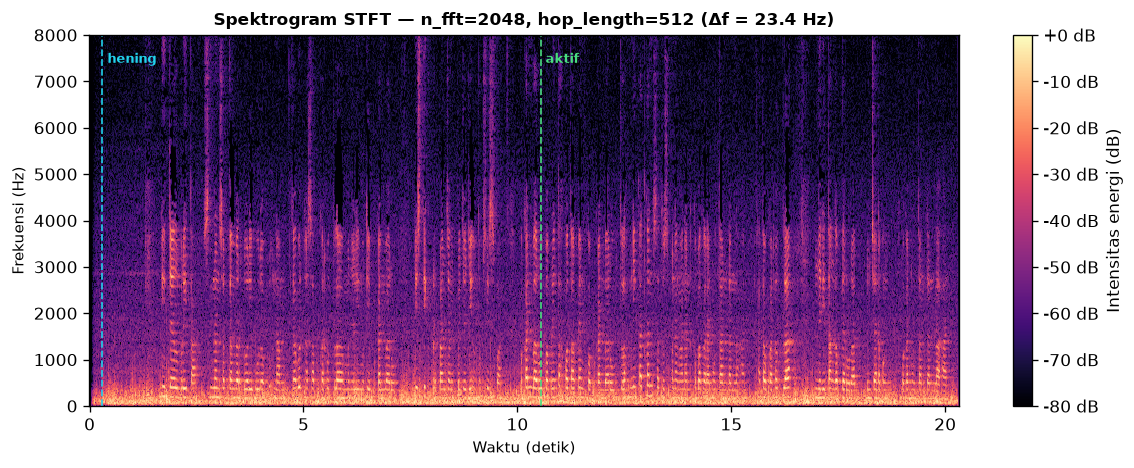

In [7]:
N_FFT, HOP = 2048, 512

# n_fft=2048 di 48 kHz ngasih Δf sekitar 23 Hz dan jendela 42,7 ms. Ini
# jalan tengah: cukup halus buat misahin pita derau frekuensi rendah, tapi
# masih cukup pendek buat nangkep ketukan konsonan. hop = seperempat n_fft,
# jadi antar bingkai tumpang tindih 75%.
S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))

# Pakai amplitude_to_db karena librosa.stft ngasih MAGNITUDO. Beda sama
# Mel-spektrogram nanti yang ngasih POWER, jadi pakai power_to_db. Kalau
# ketuker, skala dB-nya meleset dua kali lipat. ref=np.max bikin titik
# paling kuat jadi acuan 0 dB.
S_db = librosa.amplitude_to_db(S, ref=np.max)

print(f"Resolusi frekuensi (Δf) : {sr/N_FFT:.2f} Hz per bin")
print(f"Panjang jendela analisis: {N_FFT/sr*1000:.2f} ms")
print(f"Dimensi spektrogram     : {S_db.shape[0]} bin × {S_db.shape[1]} bingkai\n")

fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                               x_axis='time', y_axis='linear', ax=ax, cmap='magma')
ax.set_ylim(0, 8000)
ax.set_title(f"Spektrogram STFT — n_fft={N_FFT}, hop_length={HOP} "
             f"(Δf = {sr/N_FFT:.1f} Hz)", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi (Hz)", fontsize=9)
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Intensitas energi (dB)')

# Tandai jendela hening dan aktif yang tadi dideteksi otomatis
ax.axvline(i_hening / sr, color='#22d3ee', lw=1.1, linestyle='--', alpha=0.9)
ax.axvline(i_aktif  / sr, color='#4ade80', lw=1.1, linestyle='--', alpha=0.9)
ax.text(i_hening / sr, 7400, ' hening', color='#22d3ee', fontsize=7.5, fontweight='bold')
ax.text(i_aktif  / sr, 7400, ' aktif',  color='#4ade80', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

- Tambahan: demo trade-off resolusi waktu vs frekuensi.

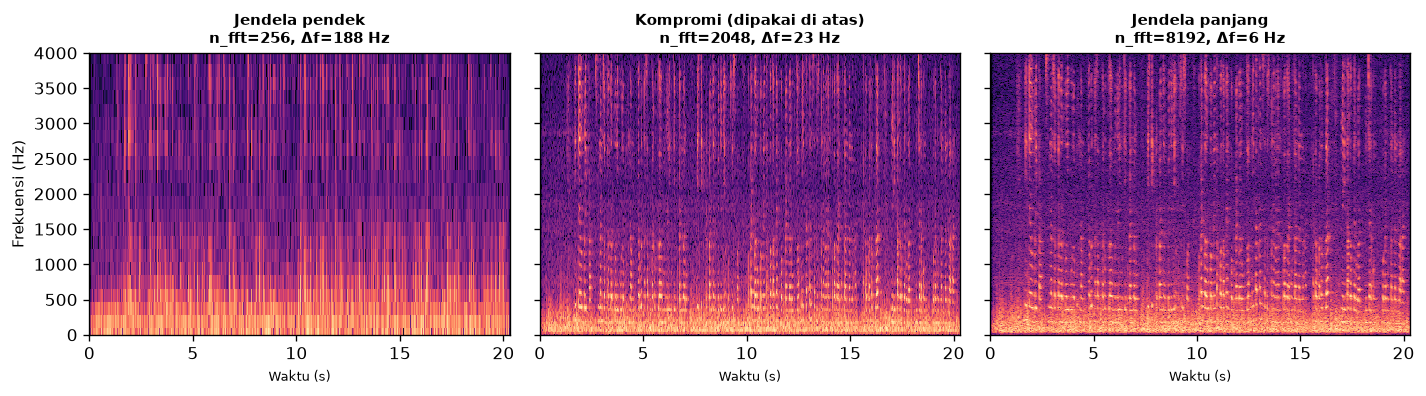

In [8]:
KONFIG = [
    (256,   64,  'Jendela pendek'),
    (2048,  512, 'Kompromi (dipakai di atas)'),
    (8192, 2048, 'Jendela panjang'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (n_fft, hop, judul) in zip(axes, KONFIG):
    S_k = librosa.amplitude_to_db(
        np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop)), ref=np.max)
    librosa.display.specshow(S_k, sr=sr, hop_length=hop, n_fft=n_fft,
                             x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.set_ylim(0, 4000)
    ax.set_title(f"{judul}\nn_fft={n_fft}, Δf={sr/n_fft:.0f} Hz",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("Waktu (s)", fontsize=8)
    ax.set_ylabel("")
axes[0].set_ylabel("Frekuensi (Hz)", fontsize=9)
plt.tight_layout()
plt.show()

Di sini dua kelemahan sebelumnya ketutup. Waveform punya waktu tapi buta frekuensi, spektrum FFT punya frekuensi tapi kehilangan waktu. Spektrogram gabungin keduanya, dengan ongkos resolusinya harus dibagi.

Dengan n_fft 2048 di 48 kHz, resolusinya 23,44 Hz per bin dan jendelanya 42,67 ms, hasilnya matriks 1025 bin frekuensi × 1905 bingkai waktu. Yang paling mencolok: pita terang di bagian bawah (sekitar 0–500 Hz) yang nyala terus dari detik nol sampai akhir. Itu noise statis. Karena sifatnya konstan, dia kelihatan sebagai garis mendatar yang stabil. Ini juga alasan tugasnya minta derau statis, bukan derau transien.

Bandingin sama bagian waktu saya baca artikel: muncul tumpukan garis mendatar bertingkat yang naik turun ikut intonasi (deret harmonik suara saya), plus coretan vertikal tipis tiap ada konsonan letup. Kontras antara garis datar punya kipas dan pola bergelombang punya vokal, itulah inti percobaannya.

Dari tiga konfigurasi jendela, kelihatan nggak ada yang menang di dua sisi. Di n_fft 256, resolusinya jadi 188 Hz, lebih kasar dari jarak antar harmonik suara saya, jadi garis-garisnya lebur jadi pita tebal. Sebaliknya di n_fft 8192, resolusinya tajam sampai 6 Hz dan tiap harmonik kelihatan jelas, tapi ketukan konsonannya jadi melar ke samping. Ini bukan salah library, tapi memang batas bawaan analisis waktu-frekuensi.

### 7. Visualisasi 4. Mel-Spektrogram

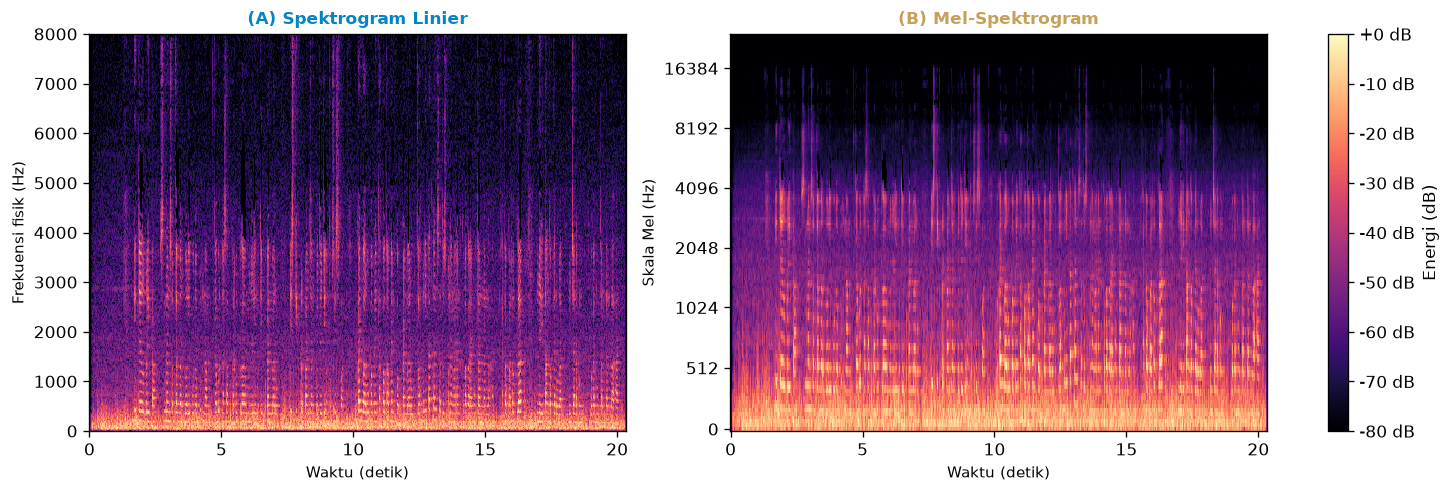

Dimensi spektrogram linier:  1025 bin × 1905 bingkai
Dimensi Mel-spektrogram   :  128 bin × 1905 bingkai
Pemampatan data           :  8.0× lebih ringkas

Porsi bin di bawah 1 kHz, skala Mel    : 25.0%
Porsi bin di bawah 1 kHz, skala linier : 4.2%
Daerah vokal diperbesar sekitar        : 6.0×


In [9]:
N_MELS = 128

# melspectrogram default-nya power=2.0, jadi hasilnya sudah dikuadratkan
# (POWER). Makanya WAJIB pakai power_to_db, bukan amplitude_to_db kayak
# magnitudo STFT di sel sebelumnya.
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT,
                                       hop_length=HOP, n_mels=N_MELS)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                         x_axis='time', y_axis='linear', ax=axes[0], cmap='magma')
axes[0].set_ylim(0, 8000)
axes[0].set_title("(A) Spektrogram Linier", fontsize=10, fontweight='bold', color=C_SIGNAL)
axes[0].set_ylabel("Frekuensi fisik (Hz)", fontsize=9)

img = librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                               x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].set_title("(B) Mel-Spektrogram", fontsize=10, fontweight='bold', color='#c5a059')
axes[1].set_ylabel("Skala Mel (Hz)", fontsize=9)

for ax in axes:
    ax.set_xlabel("Waktu (detik)", fontsize=9)
fig.colorbar(img, ax=axes, format='%+2.0f dB', label='Energi (dB)')
plt.show()

# Bukti angka bahwa skala Mel ngebesarin porsi daerah vokal
mel_f = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=sr / 2)
lin_f = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

porsi_mel = 100 * np.sum(mel_f < 1000) / N_MELS
porsi_lin = 100 * np.sum(lin_f < 1000) / len(lin_f)

print(f"Dimensi spektrogram linier: {S_db.shape[0]:>5} bin × {S_db.shape[1]} bingkai")
print(f"Dimensi Mel-spektrogram   :{S_mel_db.shape[0]:>5} bin × {S_mel_db.shape[1]} bingkai")
print(f"Pemampatan data           :  {S_db.shape[0]/S_mel_db.shape[0]:.1f}× lebih ringkas\n")
print(f"Porsi bin di bawah 1 kHz, skala Mel    : {porsi_mel:.1f}%")
print(f"Porsi bin di bawah 1 kHz, skala linier : {porsi_lin:.1f}%")
print(f"Daerah vokal diperbesar sekitar        : {porsi_mel/porsi_lin:.1f}×")

Skala linier nganggep selisih 100 Hz di mana pun sama jauhnya, padahal telinga manusia nggak gitu. Dari 100 ke 200 Hz kerasa selebar satu oktaf, sedangkan dari 10.000 ke 10.100 Hz hampir nggak kedengeran bedanya.

Angkanya jelas: dari 128 bin Mel, 25% ada di bawah 1 kHz, sedangkan di bin FFT linier cuma 4,2%. Jadi daerah vokal diperbesar sekitar enam kali. Efeknya langsung kelihatan pas dua panel disandingin. Di panel linier, harmonik suara saya kejepit di sepertiga bawah, dua pertiga sisanya habis buat frekuensi tinggi yang hampir kosong. Di panel Mel, tumpukan yang sama jadi renggang dan pola artikulasinya jauh lebih jelas.

Yang keren, semua itu didapat sambil mampatin data 8×, dari 1025 bin jadi 128 bin. Yang dibuang justru bagian yang paling nggak dipeduliin telinga. Makanya model pengenal suara kayak Whisper pakai Mel-spektrogram, bukan spektrogram linier: komputasinya jauh lebih ringan tanpa ngorbanin bagian yang penting buat pendengaran.

## Menetapkan Parameter Audio Rekaman

In [10]:
from scipy import signal

FS_TARGET = 8000
M = sr // FS_TARGET # faktor desimasi

print("=== PARAMETER EKSPERIMEN RESAMPLING ===")
print(f"Laju sampel asli        : {sr} Hz")
print(f"Batas Nyquist asli      : {sr/2:.0f} Hz")
print(f"Laju sampel target      : {FS_TARGET} Hz")
print(f"Faktor desimasi (M)     : {M}")
print(f"Batas Nyquist BARU      : {FS_TARGET/2:.0f} Hz")

=== PARAMETER EKSPERIMEN RESAMPLING ===
Laju sampel asli        : 48000 Hz
Batas Nyquist asli      : 24000 Hz
Laju sampel target      : 8000 Hz
Faktor desimasi (M)     : 6
Batas Nyquist BARU      : 4000 Hz


Semua komponen di atas 4000 Hz udah nggak bisa direkam dengan benar. Kalau nggak ada filter anti-aliasing, komponen itu nggak hilang, tapi MELIPAT BALIK jadi frekuensi rendah palsu sesuai f_alias = |f - k*fs|.

### Skenario A. Naive Decimation

- SKENARIO A: desimasi naif pakai slicing, TANPA filter anti-aliasing.
- Rumusnya y[m] = x[M*m]. Sampel indeks 0, 6, 12, 18, ... disimpan, sisanya dibuang.

In [11]:
# Desimasi naif y[m] = x[6m]: ambil 1 sampel, buang 5 sampel berikutnya,
# tanpa proses apa pun dulu. Karena tidak difilter low-pass duluan, komponen
# di atas 4000 Hz nggak hilang, tapi "muncul" lagi sebagai frekuensi rendah
# palsu (aliasing). Itulah cacatnya.
y_naive = y[::M]

print("=== SKENARIO A — NAIVE DECIMATION ===")
print(f"Jumlah sampel sebelum : {len(y)} sampel @ {sr} Hz")
print(f"Jumlah sampel sesudah : {len(y_naive)} sampel @ {FS_TARGET} Hz")
print(f"Rasio pengurangan     : {len(y)/len(y_naive):.2f}×")
print(f"Durasi tetap          : {len(y_naive)/FS_TARGET:.3f} detik")

sf.write('audio_downsampled_naive.wav', y_naive, FS_TARGET, subtype='PCM_16')
print("\nBerkas tersimpan: audio_downsampled_naive.wav")
display(ipd.Audio(y_naive, rate=FS_TARGET))

=== SKENARIO A — NAIVE DECIMATION ===
Jumlah sampel sebelum : 974848 sampel @ 48000 Hz
Jumlah sampel sesudah : 162475 sampel @ 8000 Hz
Rasio pengurangan     : 6.00×
Durasi tetap          : 20.309 detik

Berkas tersimpan: audio_downsampled_naive.wav


### Skenario B. Resampling Berfilter

- SKENARIO B: resampling standar pakai polyphase FIR filter.
- resample_poly nyaring pakai LPF anti-aliasing DULU baru buang sampel, jadi komponen di atas Nyquist baru sudah diredam duluan.

In [12]:
# resample_poly nyaring dulu pakai filter FIR, baru buang sampel. Kebalikan
# dari desimasi naif yang langsung buang tanpa nyaring. Ibaratnya adonan
# disaring dulu, baru wadahnya dikosongin.
# up=1, down=6 artinya murni desimasi, tanpa interpolasi.
y_clean = signal.resample_poly(y, up=1, down=M)

# Pembanding ketiga: librosa.resample, di dalamnya juga pakai filter
y_librosa = librosa.resample(y, orig_sr=sr, target_sr=FS_TARGET)

print("=== SKENARIO B — RESAMPLING BERFILTER ===")
print(f"scipy.signal.resample_poly : {len(y_clean)} sampel")
print(f"librosa.resample           : {len(y_librosa)} sampel")
print(f"Naive decimation           : {len(y_naive)} sampel (pembanding)")

sf.write('audio_downsampled_clean.wav', y_clean, FS_TARGET, subtype='PCM_16')
print("\nBerkas tersimpan: audio_downsampled_clean.wav")
display(ipd.Audio(y_clean, rate=FS_TARGET))

=== SKENARIO B — RESAMPLING BERFILTER ===
scipy.signal.resample_poly : 162475 sampel
librosa.resample           : 162475 sampel
Naive decimation           : 162475 sampel (pembanding)

Berkas tersimpan: audio_downsampled_clean.wav


## Tahap Pembuktian

### 1. Secara visual: spektrogram komparasi

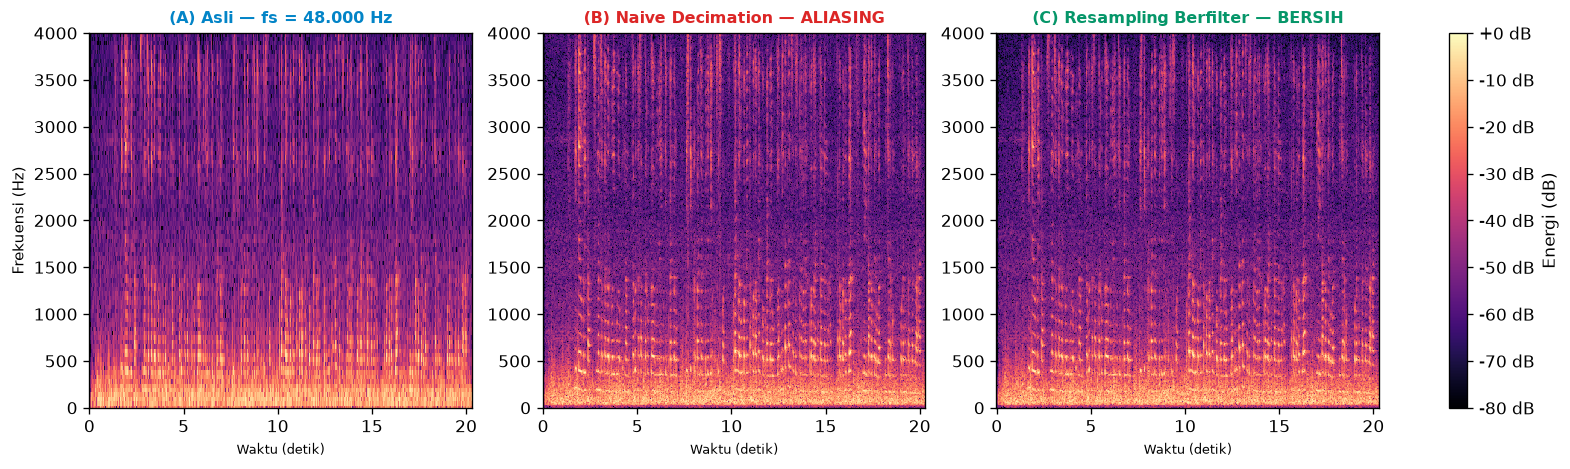

In [13]:
N_FFT_DS, HOP_DS = 1024, 256

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)

panel = [
    (y,       sr,        "(A) Asli — fs = 48.000 Hz",                 C_SIGNAL),
    (y_naive, FS_TARGET, "(B) Naive Decimation — ALIASING",           C_ALERT),
    (y_clean, FS_TARGET, "(C) Resampling Berfilter — BERSIH",         C_GOOD),
]

for ax, (sig, fs_p, judul, warna) in zip(axes, panel):
    S_p = librosa.amplitude_to_db(
        np.abs(librosa.stft(sig, n_fft=N_FFT_DS, hop_length=HOP_DS)), ref=np.max)
    img = librosa.display.specshow(S_p, sr=fs_p, hop_length=HOP_DS, n_fft=N_FFT_DS,
                                   x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.set_ylim(0, 4000) # disamakan agar perbandingan adil
    ax.set_title(judul, fontsize=9.5, fontweight='bold', color=warna)
    ax.set_xlabel("Waktu (detik)", fontsize=8)
    ax.set_ylabel("")

axes[0].set_ylabel("Frekuensi (Hz)", fontsize=9)
fig.colorbar(img, ax=axes, format='%+2.0f dB', label='Energi (dB)')
plt.show()

- Panel B dan C di atas kelihatan nyaris kembar. Supaya bedanya kelihatan, kedua spektrogram dikurangkan langsung.

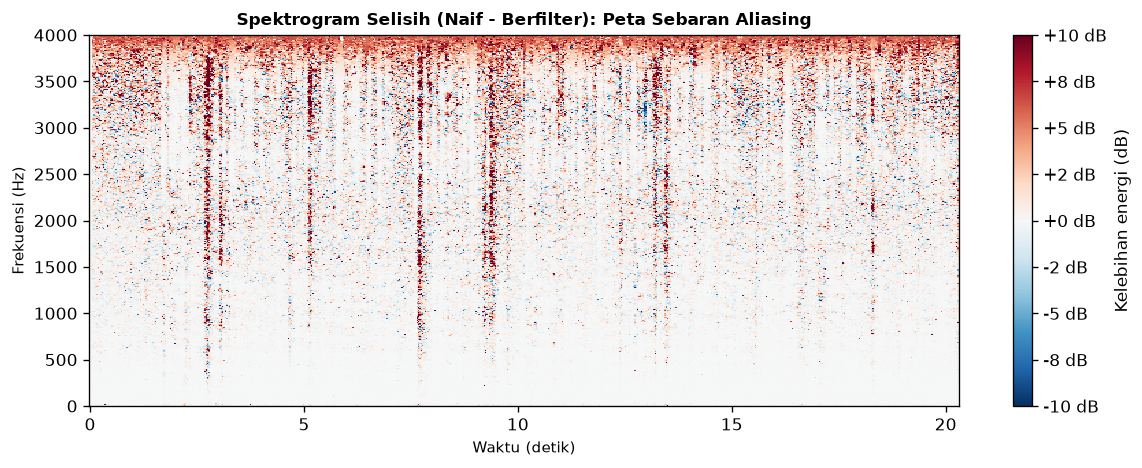

Kelebihan energi rata-rata pita 2500-4000 Hz : +1.41 dB
Nilai terendah sepanjang rekaman             : -0.22 dB (detik 12.96)
Nilai tertinggi sepanjang rekaman            : +8.05 dB (detik 2.75)


In [14]:
# Panel B dan C pada gambar sebelumnya terlihat nyaris kembar. Untuk
# memunculkan perbedaannya, kedua spektrogram dikurangkan langsung.
# ref=1.0 dipakai (BUKAN np.max) supaya kedua matriks memakai acuan dB yang
# sama. Kalau pakai np.max, masing-masing dinormalisasi ke puncaknya sendiri
# sehingga hasil pengurangannya jadi tidak bermakna.
S_nv = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_naive, n_fft=N_FFT_DS, hop_length=HOP_DS)), ref=1.0)
S_cl = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_clean, n_fft=N_FFT_DS, hop_length=HOP_DS)), ref=1.0)

D_selisih = S_nv - S_cl

# Colormap divergen dipakai supaya nilai nol berada tepat di warna netral,
# merah untuk kelebihan energi dan biru untuk kekurangan.
fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(D_selisih, sr=FS_TARGET, hop_length=HOP_DS,
                               n_fft=N_FFT_DS, x_axis='time', y_axis='linear',
                               ax=ax, cmap='RdBu_r', vmin=-10, vmax=10)
ax.set_ylim(0, 4000)
ax.set_title("Spektrogram Selisih (Naif - Berfilter): Peta Sebaran Aliasing",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi (Hz)", fontsize=9)
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Kelebihan energi (dB)')
plt.tight_layout()
plt.show()

# Sebaran menurut waktu. Pertanyaan yang dijawab di sini: apakah aliasing
# hanya muncul saat ada vokal, atau juga hadir pada jeda ketika yang
# berbunyi hanyalah deru kipas. Kalau nilai terendahnya tetap positif,
# berarti derau statis pun ikut melipat.
pita_atas = (librosa.fft_frequencies(sr=FS_TARGET, n_fft=N_FFT_DS) >= 2500)
profil = D_selisih[pita_atas].mean(axis=0)
waktu = librosa.frames_to_time(np.arange(len(profil)),
                               sr=FS_TARGET, hop_length=HOP_DS)

print(f"Kelebihan energi rata-rata pita 2500-4000 Hz : {profil.mean():+.2f} dB")
print(f"Nilai terendah sepanjang rekaman             : {profil.min():+.2f} dB "
      f"(detik {waktu[np.argmin(profil)]:.2f})")
print(f"Nilai tertinggi sepanjang rekaman            : {profil.max():+.2f} dB "
      f"(detik {waktu[np.argmax(profil)]:.2f})")

### 2. Secara kuantitatif

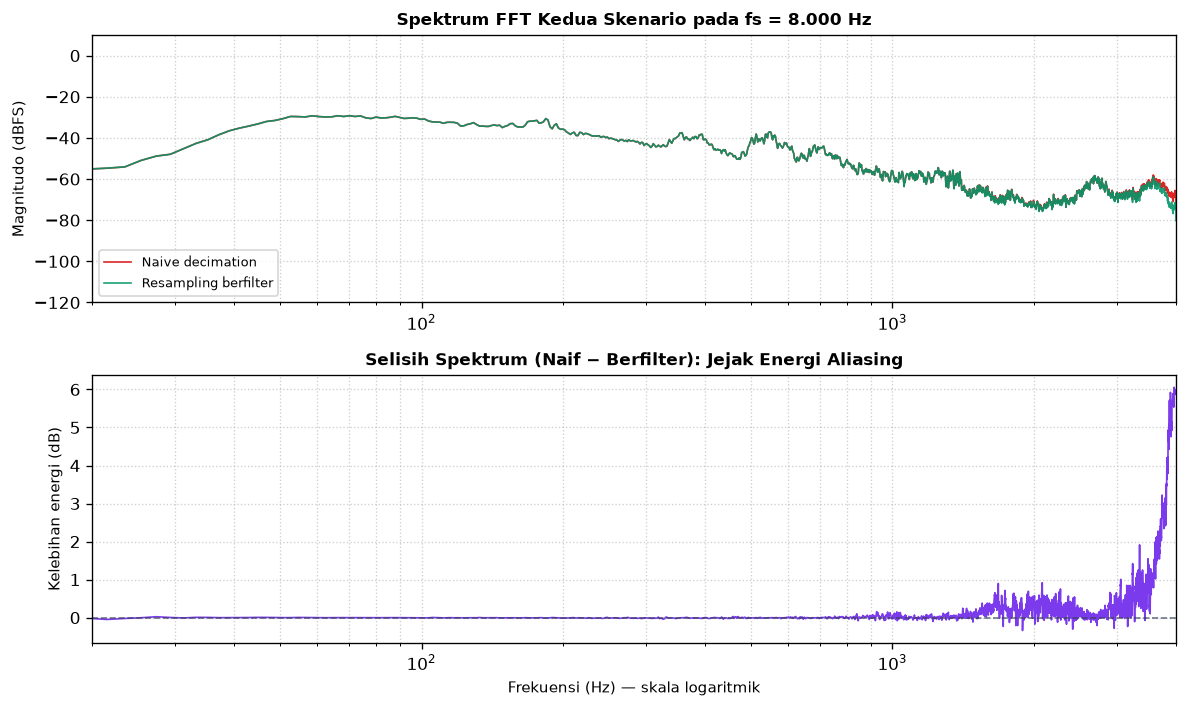

=== KELEBIHAN ENERGI PADA SKENARIO NAIF ===
     20–500   Hz :  -0.01 dB rata-rata
    500–1500  Hz :  +0.02 dB rata-rata
   1500–2500  Hz :  +0.24 dB rata-rata
   2500–4000  Hz :  +1.23 dB rata-rata

Kelebihan energi terbesar: +6.06 dB di frekuensi 3964.8 Hz


In [15]:
freqs_ds, db_naive = spectrum_dbfs(y_naive, FS_TARGET, n_fft=4096)
_,        db_clean = spectrum_dbfs(y_clean, FS_TARGET, n_fft=4096)

selisih = db_naive - db_clean

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].semilogx(freqs_ds[1:], db_naive[1:], color=C_ALERT, lw=1.0,
                 label='Naive decimation')
axes[0].semilogx(freqs_ds[1:], db_clean[1:], color=C_GOOD, lw=1.0, alpha=0.9,
                 label='Resampling berfilter')
axes[0].set_title("Spektrum FFT Kedua Skenario pada fs = 8.000 Hz",
                  fontsize=10, fontweight='bold')
axes[0].set_ylabel("Magnitudo (dBFS)", fontsize=9)
axes[0].set_xlim(20, FS_TARGET / 2)
axes[0].set_ylim(-120, 10)
axes[0].grid(True, which='both', linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left', fontsize=8)

axes[1].semilogx(freqs_ds[1:], selisih[1:], color=C_ACCENT, lw=1.0)
axes[1].axhline(0, color=C_NEUTRAL, lw=1.0, linestyle='--', alpha=0.7)
axes[1].set_title("Selisih Spektrum (Naif − Berfilter): Jejak Energi Aliasing",
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
axes[1].set_ylabel("Kelebihan energi (dB)", fontsize=9)
axes[1].set_xlim(20, FS_TARGET / 2)
axes[1].grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Mengukur energi aliasing per zona frekuensi
print("=== KELEBIHAN ENERGI PADA SKENARIO NAIF ===")
for f_lo, f_hi in [(20, 500), (500, 1500), (1500, 2500), (2500, 4000)]:
    m = (freqs_ds >= f_lo) & (freqs_ds < f_hi)
    print(f"  {f_lo:>5}–{f_hi:<5} Hz : {selisih[m].mean():+6.2f} dB rata-rata")

i_max = np.argmax(selisih[1:]) + 1
print(f"\nKelebihan energi terbesar: {selisih[i_max]:+.2f} dB "
      f"di frekuensi {freqs_ds[i_max]:.1f} Hz")

### 3. Memetakan asal-usul aliasing

In [16]:
# Komponen asli di atas 4000 Hz bakal melipat ke f_alias = |f - 8000|
print("=== PEMETAAN LIPATAN SPEKTRAL ===")
print(f"{'f asli (Hz)':>12} {'f alias (Hz)':>14}   Keterangan")
print("-" * 58)
for f_asli in (2000, 3500, 4500, 5000, 6000, 7000, 7500, 8000, 10000, 12000):
    f_alias = abs(f_asli - FS_TARGET * round(f_asli / FS_TARGET))
    aman = "di bawah Nyquist, aman" if f_asli < FS_TARGET / 2 else "MELIPAT ke frekuensi palsu"
    print(f"{f_asli:>12} {f_alias:>14.0f}   {aman}")

# Seberapa banyak energi asli yang ada di zona bahaya
freqs_asli, db_asli = spectrum_dbfs(y, sr, n_fft=8192)
zona_aman   = freqs_asli < FS_TARGET / 2
zona_bahaya = (freqs_asli >= FS_TARGET / 2) & (freqs_asli <= sr / 2)

e_aman   = np.sum(10 ** (db_asli[zona_aman]   / 10))
e_bahaya = np.sum(10 ** (db_asli[zona_bahaya] / 10))

print(f"\nProporsi energi sinyal asli di atas {FS_TARGET/2:.0f} Hz "
      f"(zona yang akan melipat): {100*e_bahaya/(e_aman+e_bahaya):.2f}%")

=== PEMETAAN LIPATAN SPEKTRAL ===
 f asli (Hz)   f alias (Hz)   Keterangan
----------------------------------------------------------
        2000           2000   di bawah Nyquist, aman
        3500           3500   di bawah Nyquist, aman
        4500           3500   MELIPAT ke frekuensi palsu
        5000           3000   MELIPAT ke frekuensi palsu
        6000           2000   MELIPAT ke frekuensi palsu
        7000           1000   MELIPAT ke frekuensi palsu
        7500            500   MELIPAT ke frekuensi palsu
        8000              0   MELIPAT ke frekuensi palsu
       10000           2000   MELIPAT ke frekuensi palsu
       12000           4000   MELIPAT ke frekuensi palsu

Proporsi energi sinyal asli di atas 4000 Hz (zona yang akan melipat): 0.02%


### 4. Memisahkan aliasing dari peredaman filter

Grafik selisih tadi membandingkan naif terhadap berfilter, sehingga dua efek yang berbeda tercampur jadi satu. Dengan mengganti acuannya ke spektrum asli, keduanya bisa diurai.

In [17]:
# Grafik selisih sebelumnya membandingkan naif terhadap berfilter, sehingga
# mencampur dua hal sekaligus: energi palsu yang MASUK akibat aliasing, dan
# energi sah yang HILANG karena diredam filter. Dengan menjadikan spektrum
# ASLI sebagai acuan bersama, keduanya dapat diurai satu per satu.
#
# CATATAN PENTING soal pemilihan n_fft. Kedua spektrum wajib punya lebar bin
# (Delta f) yang SAMA, kalau tidak levelnya tidak sebanding sama sekali.
# Sinyal yang mirip derau menyebarkan energinya ke seluruh bin, jadi bin yang
# lebih lebar menampung lebih banyak energi dan otomatis terbaca lebih tinggi.
# Memakai n_fft=8192 pada 48 kHz menghasilkan bin 5,86 Hz, tiga kali lebih
# lebar daripada bin 1,95 Hz pada analisis 8 kHz, dan itu menggeser seluruh
# pembacaan sebesar 10*log10(3) = 4,77 dB. Karena laju sampel aslinya 6 kali
# lebih besar, n_fft-nya juga harus 6 kali lebih besar:
#     8000 / 4096   = 1,953 Hz per bin
#     48000 / 24576 = 1,953 Hz per bin
# Bonusnya, hop waktu kedua analisis ikut sama (0,256 detik), sehingga jumlah
# bingkai yang dirata-ratakan juga setara.
N_FFT_ASLI = 4096 * M                       # 24576
freqs48, db48 = spectrum_dbfs(y, sr, n_fft=N_FFT_ASLI)

print("=== PEMERIKSAAN KESEPADANAN ANALISIS ===")
print(f"Delta f analisis 48 kHz : {sr/N_FFT_ASLI:.3f} Hz per bin")
print(f"Delta f analisis 8 kHz  : {FS_TARGET/4096:.3f} Hz per bin")
print(f"Hop waktu 48 kHz        : {(N_FFT_ASLI//2)/sr:.3f} detik")
print(f"Hop waktu 8 kHz         : {2048/FS_TARGET:.3f} detik\n")

# Kisi frekuensinya tetap berbeda titik-titiknya, jadi spektrum asli
# diinterpolasi ke kisi 8 kHz supaya bisa dikurangkan bin per bin.
db_asli_pada_kisi = np.interp(freqs_ds, freqs48, db48)

tambahan_alias = db_naive - db_asli_pada_kisi   # energi palsu yang MASUK
redaman_filter = db_clean - db_asli_pada_kisi   # energi sah yang HILANG

print("=== URAIAN DUA EFEK YANG SEBELUMNYA TERCAMPUR ===")
print(f"{'Pita (Hz)':>14} {'Alias masuk':>14} {'Filter meredam':>16}")
print("-" * 48)
for f_lo, f_hi in [(20, 500), (500, 1500), (1500, 2500), (2500, 3500), (3500, 4000)]:
    m = (freqs_ds >= f_lo) & (freqs_ds < f_hi)
    print(f"{f_lo:>6}-{f_hi:<7} {tambahan_alias[m].mean():>+13.2f} dB "
          f"{redaman_filter[m].mean():>+14.2f} dB")

# Verifikasi rumus lipatan pada puncak yang benar-benar terukur di data ini,
# bukan sekadar contoh angka bulat pada tabel teoretis di sel sebelumnya.
f_puncak = freqs_ds[i_max]
f_sumber = FS_TARGET - f_puncak
print(f"\nPuncak kelebihan energi terukur di : {f_puncak:.1f} Hz")
print(f"Menurut f_alias = |f - fs|, asalnya : {f_sumber:.1f} Hz")
print(f"Jarak sumber di atas Nyquist baru   : {f_sumber - FS_TARGET/2:.1f} Hz")

=== PEMERIKSAAN KESEPADANAN ANALISIS ===
Delta f analisis 48 kHz : 1.953 Hz per bin
Delta f analisis 8 kHz  : 1.953 Hz per bin
Hop waktu 48 kHz        : 0.256 detik
Hop waktu 8 kHz         : 0.256 detik

=== URAIAN DUA EFEK YANG SEBELUMNYA TERCAMPUR ===
     Pita (Hz)    Alias masuk   Filter meredam
------------------------------------------------
    20-500             +0.00 dB          +0.01 dB
   500-1500            +0.02 dB          +0.01 dB
  1500-2500            +0.24 dB          +0.00 dB
  2500-3500            +0.31 dB          -0.01 dB
  3500-4000            +1.19 dB          -1.86 dB

Puncak kelebihan energi terukur di : 3964.8 Hz
Menurut f_alias = |f - fs|, asalnya : 4035.2 Hz
Jarak sumber di atas Nyquist baru   : 35.2 Hz


Turun dari 48 kHz ke 8 kHz berarti faktor desimasinya enam. Yang paling penting, batas Nyquist anjlok dari 24.000 Hz jadi cuma 4.000 Hz. Seluruh rentang 4.000 sampai 24.000 Hz yang tadinya sah sekarang berubah status jadi zona bahaya.

Dua skenario ngasih jumlah sampel yang persis sama, 162.475 sampel, dan durasinya juga nggak berubah. Bedanya cuma di urutan kerja. Desimasi naif langsung buang lima dari tiap enam sampel, sedangkan resample_poly nyaring dulu baru buang. Urutan sesederhana itu yang nentuin hasilnya. Waktu didengerin bolak-balik, versi naif kedengeran sedikit lebih kasar dan huruf S-nya berdesis nggak wajar, tapi jujur aja bedanya tipis banget dan harus fokus dulu baru kerasa.

Nah, soal spektrogram komparasinya, saya harus jujur. Panel B dan panel C kelihatan nyaris kembar. Nggak ada pola V dramatis kayak contoh chirp di materi kuliah. Perbedaannya cuma semburat samar di atas 2500 Hz yang gampang kelewat kalau cuma dipelototi sekilas. Makanya saya bikin spektrogram selisih, dan di situ barulah kelihatan bahwa kelebihan energinya nempel di pita atas.

Sebaran menurut waktu juga saya ukur, dan hasilnya justru membantah dugaan awal saya. Tadinya saya pikir deru kipas bakal ikut nyumbang aliasing, soalnya sifatnya broadband, bukan dengung tonal. Ternyata nggak gitu. Kelebihan energi rata-ratanya emang +1,41 dB, tapi rentangnya ngayun lebar banget: dari -0,22 dB di detik 12,96 sampai +8,05 dB di detik 2,75. Nah, deru kipas itu levelnya konstan sepanjang rekaman. Kalau dia yang jadi penggerak aliasing, kelebihan energinya harusnya ikut rata juga. Kenyataannya ngayun sampai delapan desibel. Jadi yang nggerakin aliasing itu konten yang berubah-ubah, yaitu suara saya sendiri, khususnya konsonan desis kayak S dan SY yang energinya nyampe ke atas 4 kHz. Kipasnya sendiri ternyata energinya udah keburu habis sebelum 4 kHz, jadi nggak nyisa banyak buat dilipat. Dugaan saya meleset, tapi datanya jelas.

Secara angka, polanya rapi. Di 20-500 Hz selisihnya -0,01 dB alias nggak ada. Di 500-1500 Hz cuma +0,02 dB. Baru kerasa di 1500-2500 Hz (+0,24 dB), terus naik ke rata-rata +1,23 dB di 2500-4000 Hz, dengan puncak +6,06 dB pas di 3964,8 Hz. Kalau puncak itu saya balikin pakai rumus f_alias = |f - fs|, sumbernya ada di 8000 - 3964,8 = 4035,2 Hz, cuma 35 Hz di atas batas Nyquist baru. Jadi tabel lipatan spektral yang saya tulis tadi bukan cuma hitungan di atas kertas, tapi kebukti langsung di data saya sendiri.

Tapi ada satu hal yang gampang disalahartikan. Selisih di dekat 4000 Hz itu nggak semuanya aliasing murni. Sebagian datang dari lereng transisi filter anti-aliasing di resample_poly, yang memang udah mulai ngeredam dikit sebelum nyampe batas. Buat misahin keduanya, saya bandingin lagi tapi acuannya diganti ke spektrum asli. Di sini ada jebakan teknis yang sempat bikin saya salah baca: kedua spektrum harus punya lebar bin yang sama persis. Waktu pertama saya coba pakai n_fft 8192 di 48 kHz lawan 4096 di 8 kHz, semua angkanya kegeser konstan sekitar -4,7 dB. Ternyata itu bukan fisika, tapi efek lebar bin: bin yang tiga kali lebih lebar nampung tiga kali lebih banyak energi derau, dan 10*log10(3) itu 4,77 dB. Setelah n_fft-nya disesuain jadi 24576 biar Delta f-nya sama-sama 1,953 Hz, barulah dua efeknya keurai beneran. Hasilnya rapi banget. Di 20-1500 Hz dua kolomnya sama-sama nol, artinya di wilayah itu desimasi naif maupun berfilter nggak ngerusak apa-apa. Aliasing baru kelihatan masuk di 1500-2500 Hz (+0,24 dB) dan 2500-3500 Hz (+0,31 dB), dan yang menarik di dua pita ini filternya sama sekali nggak ngeredam (0,00 dan -0,01 dB). Jadi kelebihan energi di situ murni aliasing, nggak ada campuran apa pun. Menurut saya justru di pita inilah bukti aliasing paling bersih, bukan di puncak dekat 4000 Hz yang selama ini saya kira paling meyakinkan. Barulah di 3500-4000 Hz dua efeknya ketemu: alias nambah +1,19 dB sementara filter ngeredam -1,86 dB. Kalau dihitung, selisih naif dikurangi berfilter di pita itu jadi sekitar +3,05 dB, dan ternyata penyumbang terbesarnya malah peredaman filter, bukan aliasingnya. Persis kayak yang saya khawatirin tadi, cuma sekarang kebukti pakai angka.

Hal terakhir, efeknya emang tipis. Energi sinyal asli di atas 4000 Hz ternyata cuma 0,02%. Wajar, energi suara manusia numpuk di bawah 4 kHz, ditambah pita atas rekaman ini udah duluan dipotong encoder AAC bawaan iPhone. Kalau pakai chirp yang nyapu sampai 7,5 kHz, pola V-nya pasti muncul jelas. Di suara ngomong biasa, hukum Nyquist tetap berlaku tapi dampaknya kecil. Menurut saya ini justru temuan yang lebih berguna daripada kalau hasilnya dramatis, soalnya dia ngejelasin kenapa pipeline ASR kayak Whisper berani nurunin audio ke 16 kHz tanpa banyak kehilangan, asal filternya nggak lupa dipasang.